# Consumer Price Index Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict Consumer Price Index.

In [1]:
import pandas as pd
import numpy as np
Consumer_Price_Index_Data=pd.read_excel("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Regression projects/Consumer Price Index/Consumer_Price_Index_in_Denver.xlsx")

print(Consumer_Price_Index_Data.shape)
Consumer_Price_Index_Data.drop_duplicates()
print(Consumer_Price_Index_Data.shape)
Consumer_Price_Index_Data.head(5)

(4349, 17)
(4349, 17)


,stateFips,area,areaType,period,periodYear,periodType,periodTypeDescription,cpi,title,type,source,cpiSourceDescription,percentChangeYear,percentChangeMonth,dataRegion,areaName,areaDescription
0,0,0,0,0,1913,1,Annual,9.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",0.0,0.0,US,United States,The United States of America (commonly referre...
1,0,0,0,0,1913,1,Annual,10.0,"CPI-W all items 1982-84=100, not seasonally ad...",3,1,"US DOL, Bureau of Labor Statistics",0.0,0.0,US,United States,The United States of America (commonly referre...
2,0,0,0,1,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",0.0,-1.0,US,United States,The United States of America (commonly referre...
3,0,0,0,1,1913,3,Monthly,9.9,"CPI-W all items 1982-84=100, not seasonally ad...",3,1,"US DOL, Bureau of Labor Statistics",0.0,-1.0,US,United States,The United States of America (commonly referre...
4,0,0,0,2,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",0.0,0.0,US,United States,The United States of America (commonly referre...


In [2]:
pd.set_option('display.max_rows',None)

In [3]:
Consumer_Price_Index_Data['periodType'].unique()

array([1, 3, 7])

In [4]:
Consumer_Price_Index_Data[(Consumer_Price_Index_Data['areaDescription']=='The United States of America (commonly referred to as the United States, the U.S., the USA, or America) is a federal constitutional republic comprising fifty states and a federal district. The country is situated mostly in central North America, where its forty-eight contiguous states and Washington, D.C., the capital district, lie between the Pacific and Atlantic Oceans, bordered by Canada to the north and Mexico to the south. The state of Alaska is in the northwest of the continent, with Canada to its east and Russia to the west across the Bering Strait. The state of Hawaii is an archipelago in the mid-Pacific. The country also possesses several territories in the Caribbean and Pacific.')].shape

(4095, 17)

In [5]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['areaDescription']=='The United States of America (commonly referred to as the United States, the U.S., the USA, or America) is a federal constitutional republic comprising fifty states and a federal district. The country is situated mostly in central North America, where its forty-eight contiguous states and Washington, D.C., the capital district, lie between the Pacific and Atlantic Oceans, bordered by Canada to the north and Mexico to the south. The state of Alaska is in the northwest of the continent, with Canada to its east and Russia to the west across the Bering Strait. The state of Hawaii is an archipelago in the mid-Pacific. The country also possesses several territories in the Caribbean and Pacific.','areaDescription']='The United States of America'

In [6]:
Consumer_Price_Index_Data.groupby('areaDescription').size()

areaDescription
Denver CPI region                254
The United States of America    4095
dtype: int64

### Not useful columns:Eliminate :'period', 'cpiSourceDescription','source','areaDescription','dataRegion'

In [7]:
Consumer_Price_Index_Data.drop(['period', 'cpiSourceDescription','source','dataRegion'],axis=1,inplace=True)

In [8]:
Consumer_Price_Index_Data.head()

,stateFips,area,areaType,periodYear,periodType,periodTypeDescription,cpi,title,type,percentChangeYear,percentChangeMonth,areaName,areaDescription
0,0,0,0,1913,1,Annual,9.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,0.0,United States,The United States of America
1,0,0,0,1913,1,Annual,10.0,"CPI-W all items 1982-84=100, not seasonally ad...",3,0.0,0.0,United States,The United States of America
2,0,0,0,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,-1.0,United States,The United States of America
3,0,0,0,1913,3,Monthly,9.9,"CPI-W all items 1982-84=100, not seasonally ad...",3,0.0,-1.0,United States,The United States of America
4,0,0,0,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,0.0,United States,The United States of America


## Target Variable is cpi

<Axes: >

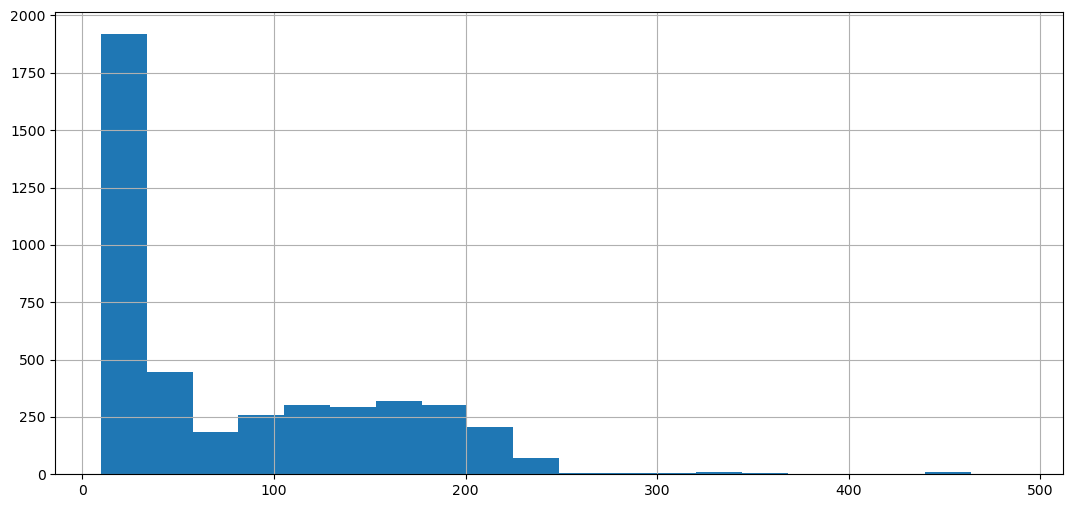

In [9]:
Consumer_Price_Index_Data['cpi'].hist(bins=20,figsize=(13,6))

### There is need to outlier treatment

In [10]:
Consumer_Price_Index_Data.nunique()

stateFips                   2
area                        2
areaType                    2
periodYear                102
periodType                  3
periodTypeDescription       3
cpi                      1639
title                      13
type                       13
percentChangeYear         293
percentChangeMonth        113
areaName                    2
areaDescription             2
dtype: int64

In [11]:
Consumer_Price_Index_Data.columns

Index(['stateFips', 'area', 'areaType', 'periodYear', 'periodType',
       'periodTypeDescription', 'cpi', 'title', 'type', 'percentChangeYear',
       'percentChangeMonth', 'areaName', 'areaDescription'],
      dtype='object')

## categoricalColumns:['stateFips', 'area', 'areaType', 'periodYear', 'periodType','periodTypeDescription','title','type','areaName','areaDescription']
## continousColumns:['cpi','percentChangeYear', 'percentChangeMonth'] 

In [12]:
Consumer_Price_Index_Data.head(2)

,stateFips,area,areaType,periodYear,periodType,periodTypeDescription,cpi,title,type,percentChangeYear,percentChangeMonth,areaName,areaDescription
0,0,0,0,1913,1,Annual,9.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,0.0,United States,The United States of America
1,0,0,0,1913,1,Annual,10.0,"CPI-W all items 1982-84=100, not seasonally ad...",3,0.0,0.0,United States,The United States of America


In [13]:
Consumer_Price_Index_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   stateFips              4349 non-null   int64  
 1   area                   4349 non-null   int64  
 2   areaType               4349 non-null   int64  
 3   periodYear             4349 non-null   int64  
 4   periodType             4349 non-null   int64  
 5   periodTypeDescription  4349 non-null   object 
 6   cpi                    4349 non-null   float64
 7   title                  4349 non-null   object 
 8   type                   4349 non-null   int64  
 9   percentChangeYear      4349 non-null   float64
 10  percentChangeMonth     4131 non-null   float64
 11  areaName               4349 non-null   object 
 12  areaDescription        4349 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 441.8+ KB


In [14]:
Consumer_Price_Index_Data.describe()

,stateFips,area,areaType,periodYear,periodType,cpi,type,percentChangeYear,percentChangeMonth
count,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4131.000000
mean,0.467234,0.116808,1.401702,1970.362382,3.030352,83.272986,4.733042,3.415797,0.269354
std,1.876266,0.469066,5.628797,27.354856,0.942212,73.970614,11.064200,4.430625,1.060419
min,0.000000,0.000000,0.000000,1913.000000,1.000000,9.700000,1.000000,-15.800000,-8.600000
25%,0.000000,0.000000,0.000000,1951.000000,3.000000,25.500000,1.000000,1.300000,0.000000
50%,0.000000,0.000000,0.000000,1972.000000,3.000000,42.400000,3.000000,2.900000,0.200000
75%,0.000000,0.000000,0.000000,1994.000000,3.000000,142.600000,3.000000,4.700000,0.500000
max,8.000000,2.000000,24.000000,2014.000000,7.000000,487.877000,59.000000,23.700000,11.200000


### Uni Variate Analysis by Histogram

array([[<Axes: title={'center': 'cpi'}>,
        <Axes: title={'center': 'percentChangeYear'}>],
       [<Axes: title={'center': 'percentChangeMonth'}>,
        <Axes: title={'center': 'periodYear'}>]], dtype=object)

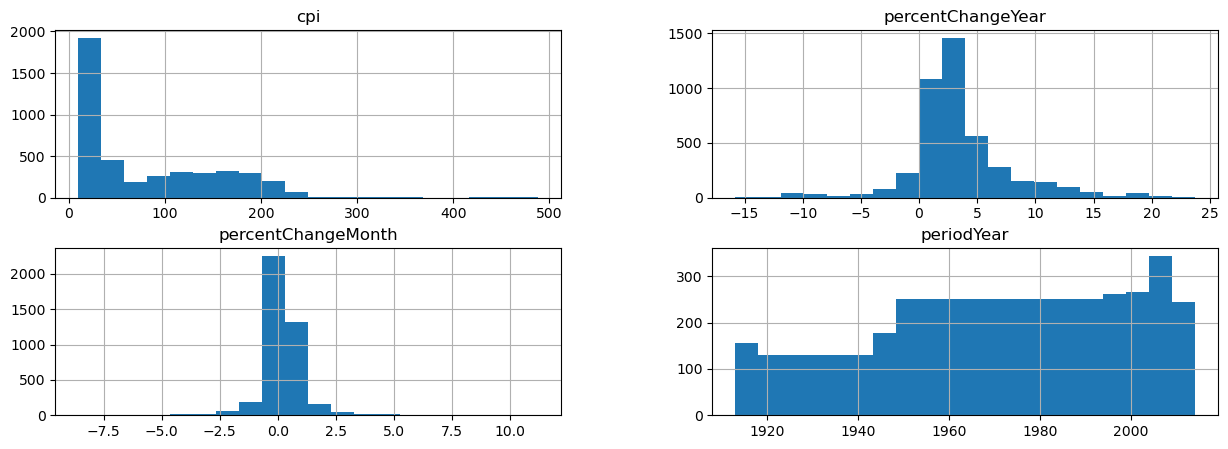

In [15]:
continousColumns=['cpi','percentChangeYear', 'percentChangeMonth','periodYear']
Consumer_Price_Index_Data[continousColumns].hist(bins=20,figsize=(15,5))

## Outlier Treatment

In [16]:
Consumer_Price_Index_Data['cpi'][Consumer_Price_Index_Data['cpi']<400].sort_values(ascending=False).head(15)

1772    388.400
1593    378.200
1691    367.900
1407    359.100
1203    352.100
4348    351.975
4342    347.953
1309    345.100
4332    341.039
4294    338.000
4321    335.800
4304    333.700
4276    333.100
4314    331.600
4285    328.200
Name: cpi, dtype: float64

In [17]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['cpi']>400,'cpi']=388.400

<Axes: >

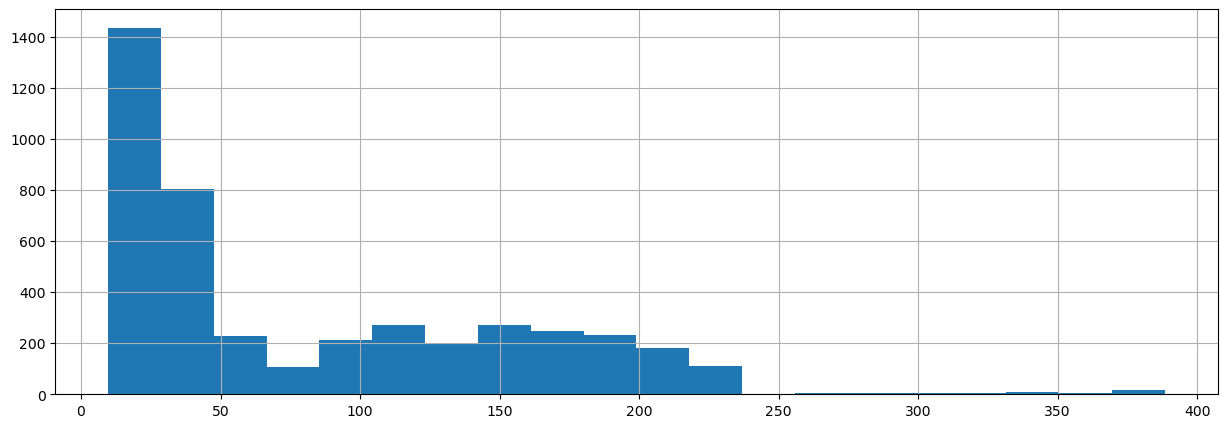

In [18]:
Consumer_Price_Index_Data['cpi'].hist(bins=20,figsize=(15,5))

## Uni Variate Analysis by Bar Charts

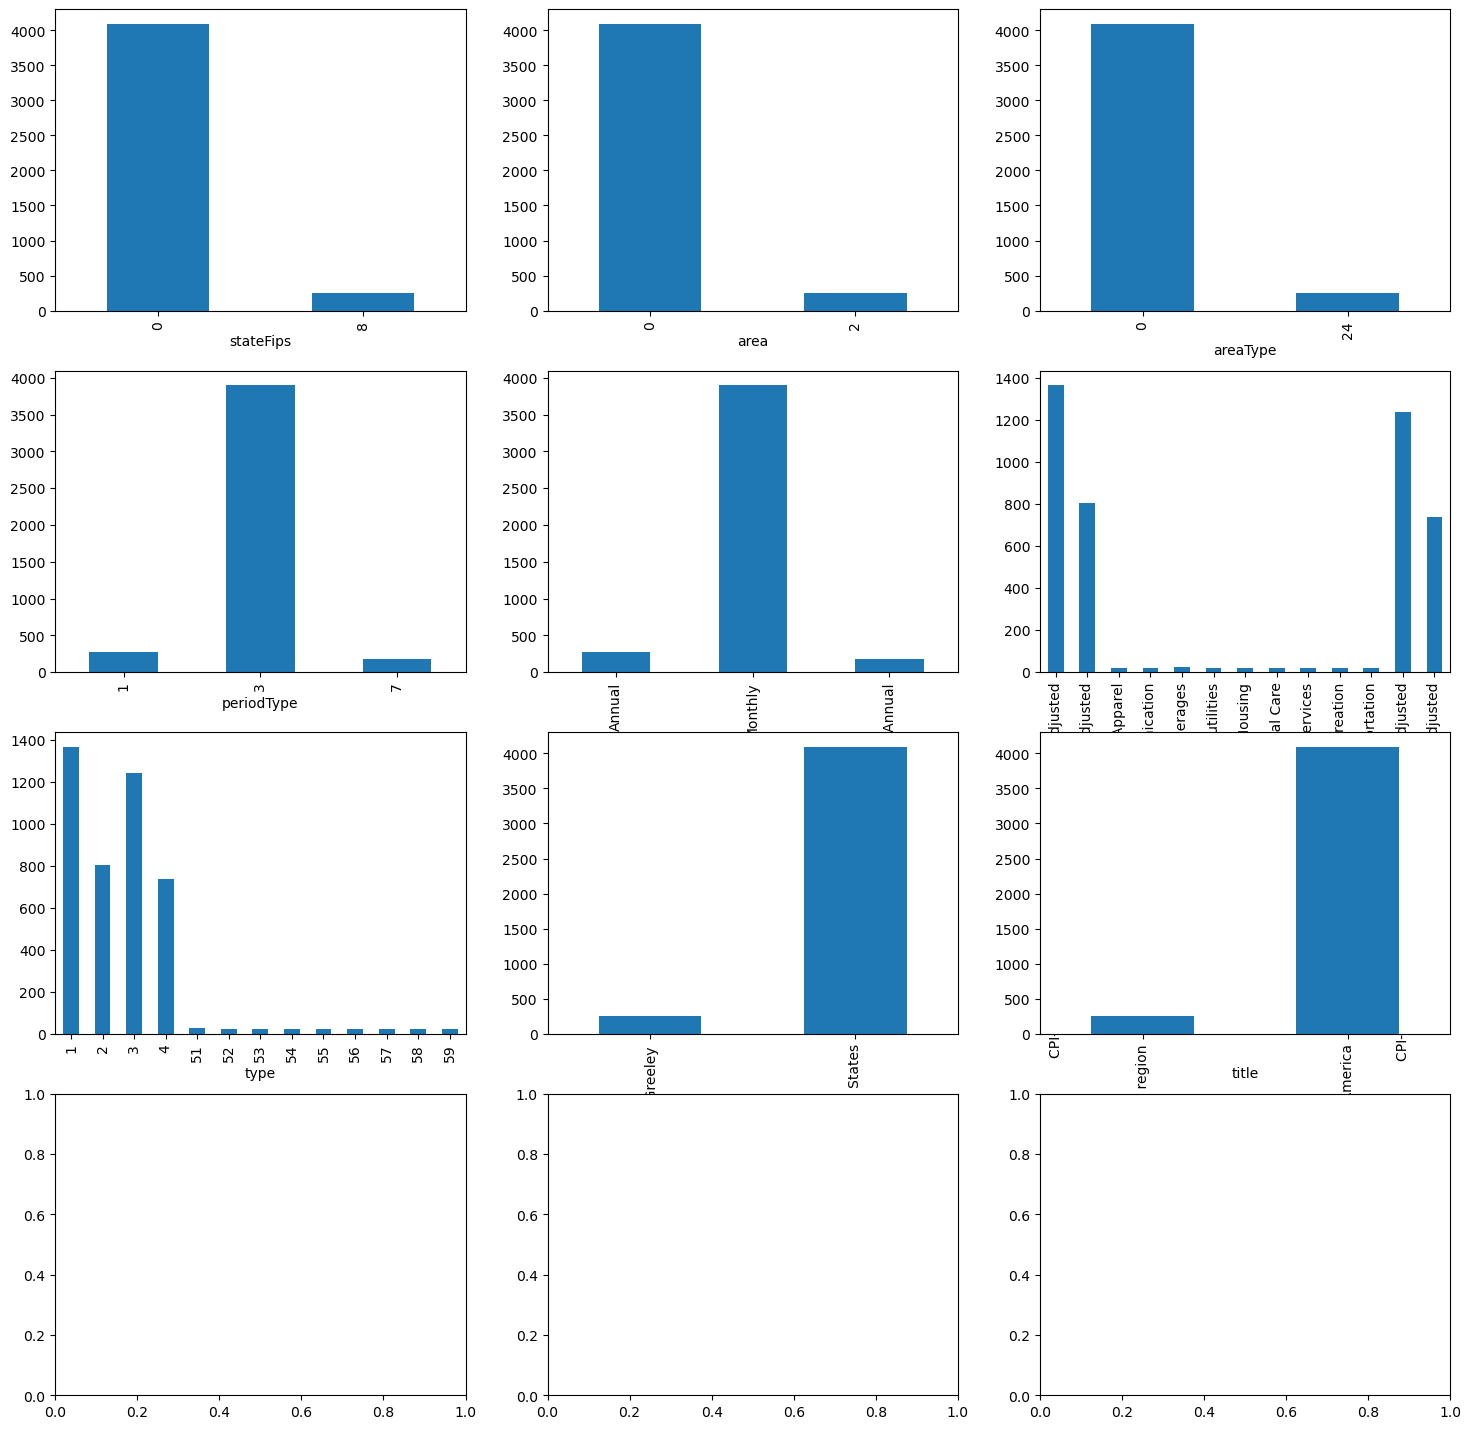

In [19]:
categoricalColumns=['stateFips', 'area', 'areaType', 'periodType','periodTypeDescription','title','type','areaName','areaDescription']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(4,3,figsize=(18,18))
subplots=subplots.flatten()
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Consumer_Price_Index_Data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

If Accuracy of model is not getting jnto required limit then eliminate this columns as these are not good for Machine Learning:['stateFips', 'area', 'areaType','areaName']

## Imbalance Treatment

In [20]:
Consumer_Price_Index_Data['type']=Consumer_Price_Index_Data['type'].astype(str)


In [21]:
Consumer_Price_Index_Data['periodType']=Consumer_Price_Index_Data['periodType'].astype(str)

In [22]:
Consumer_Price_Index_Data['periodType'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 4349 entries, 0 to 4348
Series name: periodType
Non-Null Count  Dtype 
--------------  ----- 
4349 non-null   object
dtypes: object(1)
memory usage: 34.1+ KB


In [23]:
Consumer_Price_Index_Data['periodType'].unique()

array(['1', '3', '7'], dtype=object)

In [24]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['periodType'].isin(['1','7']),'periodType']='Others'
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['periodTypeDescription']=='Semi-Annual','periodTypeDescription']='Annual'
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['title'].isin(['CPI-U:  Transportation','CPI-U:  Recreation','CPI-U:  Other goods and services',
     'CPI-U:  Medical Care','CPI-U:  Housing','CPI-U:  Fuels and utilities','CPI-U:  Food and beverages','CPI-U:  Education and communication',
    'CPI-U:  Apparel']),'title']='Others'
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['type'].isin([ '51','52', '53', '54', '55', '56', '57', '58', '59']),'type']='>51' 

<Axes: ylabel='title'>

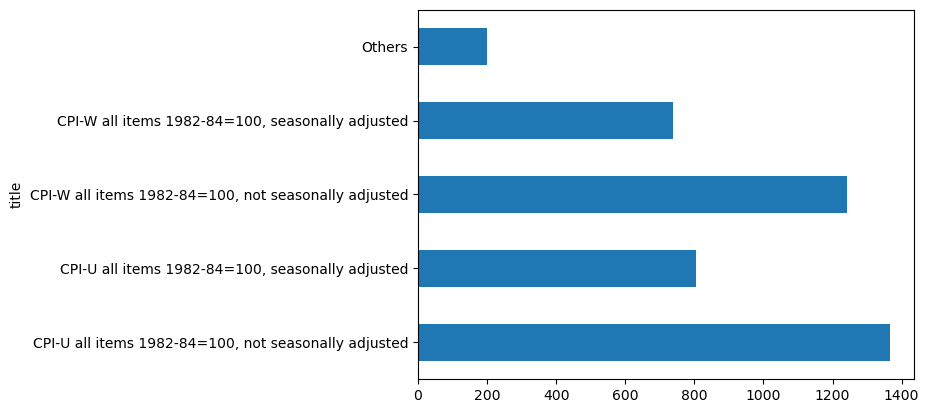

In [25]:
Consumer_Price_Index_Data.groupby('title').size().plot(kind='barh')

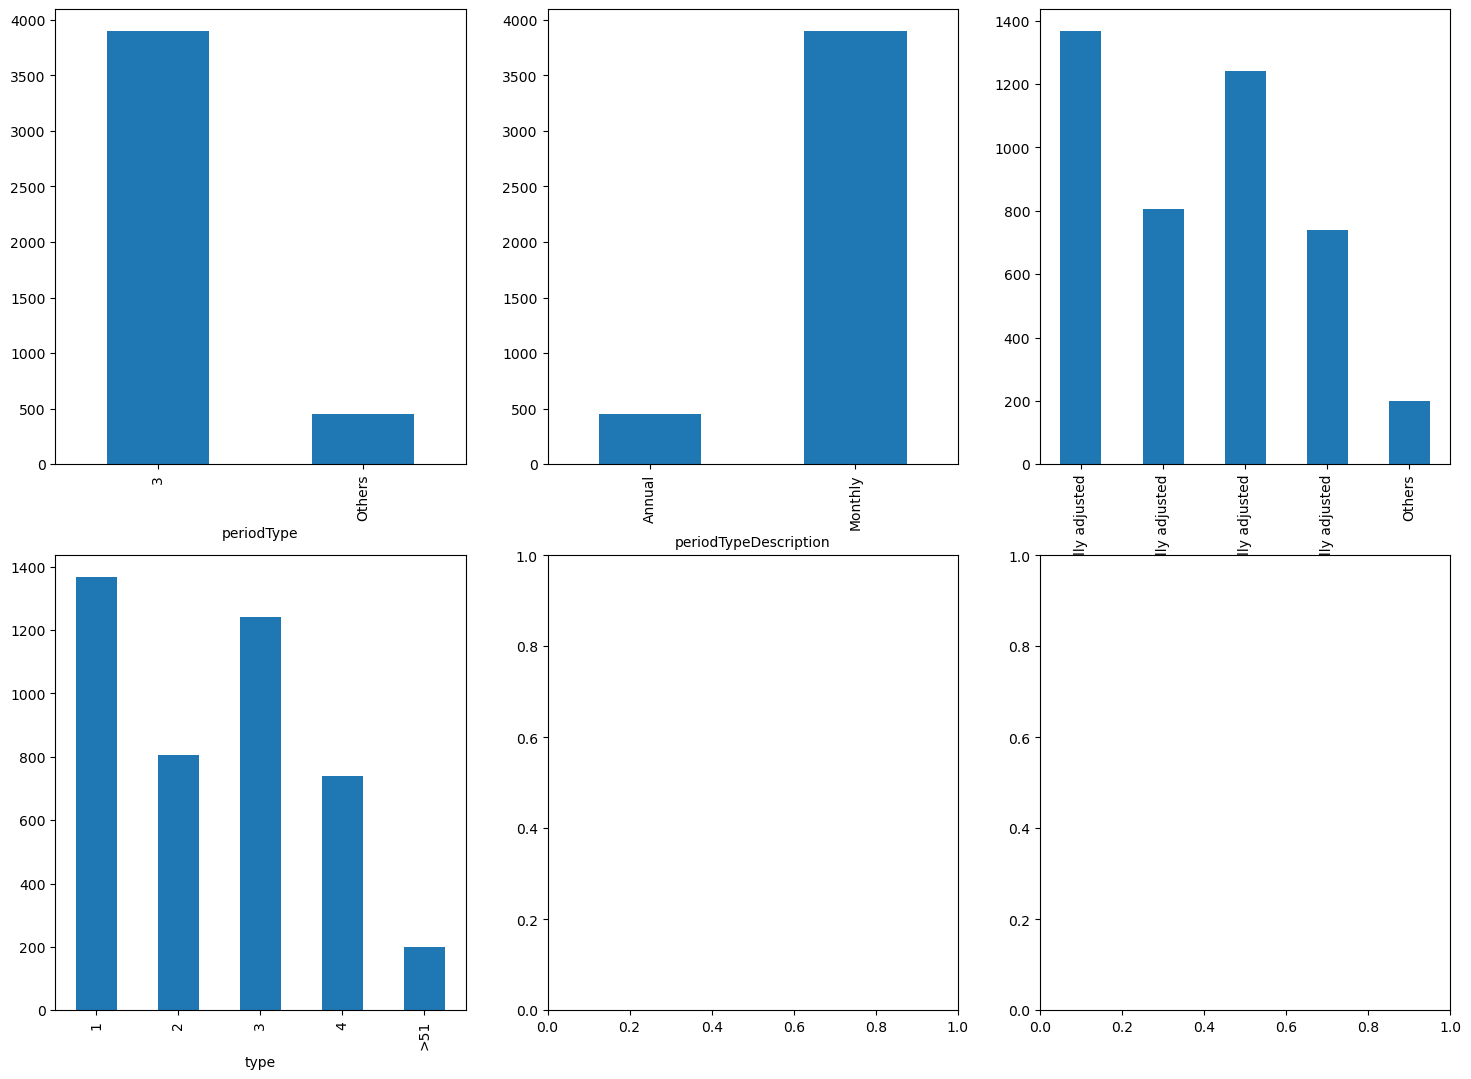

In [26]:
categoricalColumns=[ 'periodType','periodTypeDescription','title','type']
import matplotlib.pyplot as plt 
fig,subplots=plt.subplots(2,3,figsize=(18,13))
subplots=subplots.flatten()
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Consumer_Price_Index_Data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

## Missing Value Treatment:

In [27]:
Consumer_Price_Index_Data.isnull().sum() 

stateFips                  0
area                       0
areaType                   0
periodYear                 0
periodType                 0
periodTypeDescription      0
cpi                        0
title                      0
type                       0
percentChangeYear          0
percentChangeMonth       218
areaName                   0
areaDescription            0
dtype: int64

In [28]:
Consumer_Price_Index_Data['percentChangeMonth'].median()

0.2

In [29]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['percentChangeMonth'].isnull(),'percentChangeMonth']=0.2

In [30]:
Consumer_Price_Index_Data.isnull().sum() 

stateFips                0
area                     0
areaType                 0
periodYear               0
periodType               0
periodTypeDescription    0
cpi                      0
title                    0
type                     0
percentChangeYear        0
percentChangeMonth       0
areaName                 0
areaDescription          0
dtype: int64

## Continuous Vs Continuous -- Scatter Charts

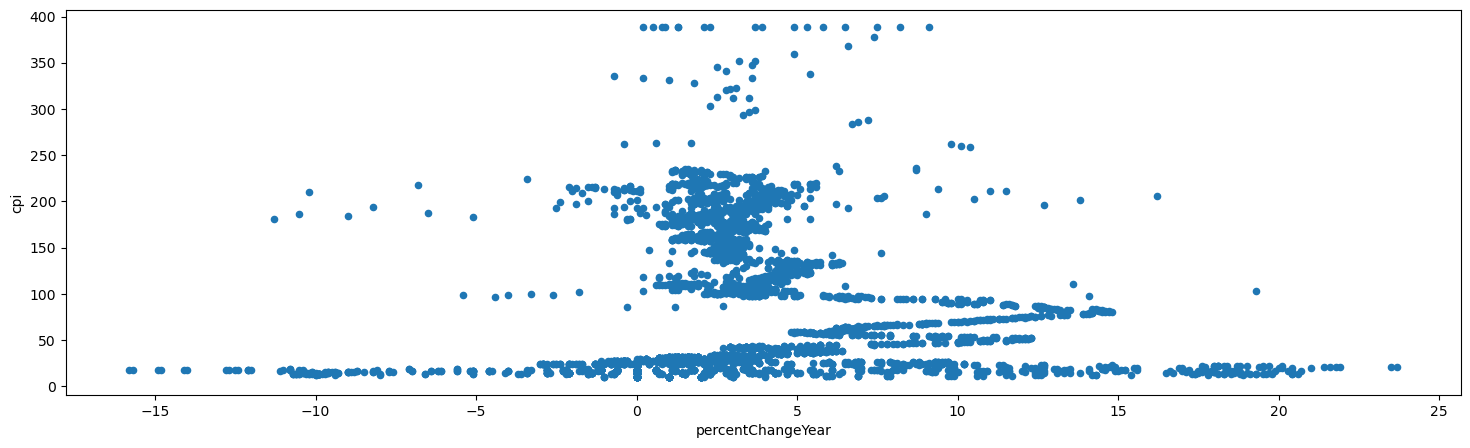

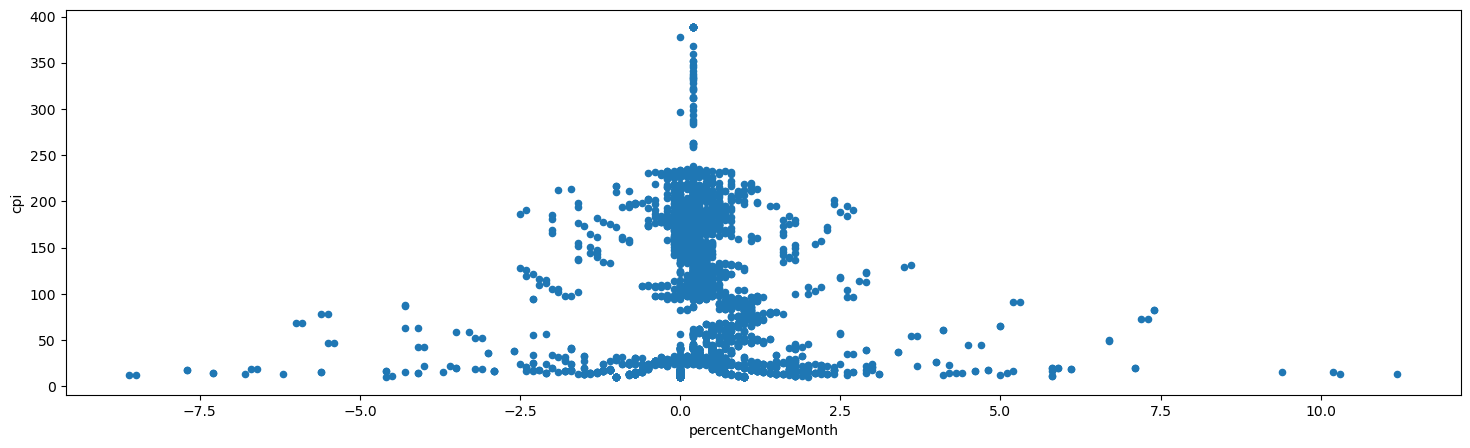

In [31]:
continousColumns=['percentChangeYear', 'percentChangeMonth']
for l in continousColumns:
    Consumer_Price_Index_Data.plot.scatter(x=l,y='cpi',figsize=(18,5))

### No clear Trend is getting

## Statistical Feature Selection (Continuous Vs Continuous) using Correlation value

In [32]:
continousColumns=['cpi','percentChangeYear', 'percentChangeMonth']
correaltionData=Consumer_Price_Index_Data[continousColumns].corr()
correaltionData

,cpi,percentChangeYear,percentChangeMonth
cpi,1.000000,0.000537,-0.004361
percentChangeYear,0.000537,1.000000,0.308690
percentChangeMonth,-0.004361,0.308690,1.000000


### There is not high correlation with cpi

## Categorical Vs Continuous -- Box Plots

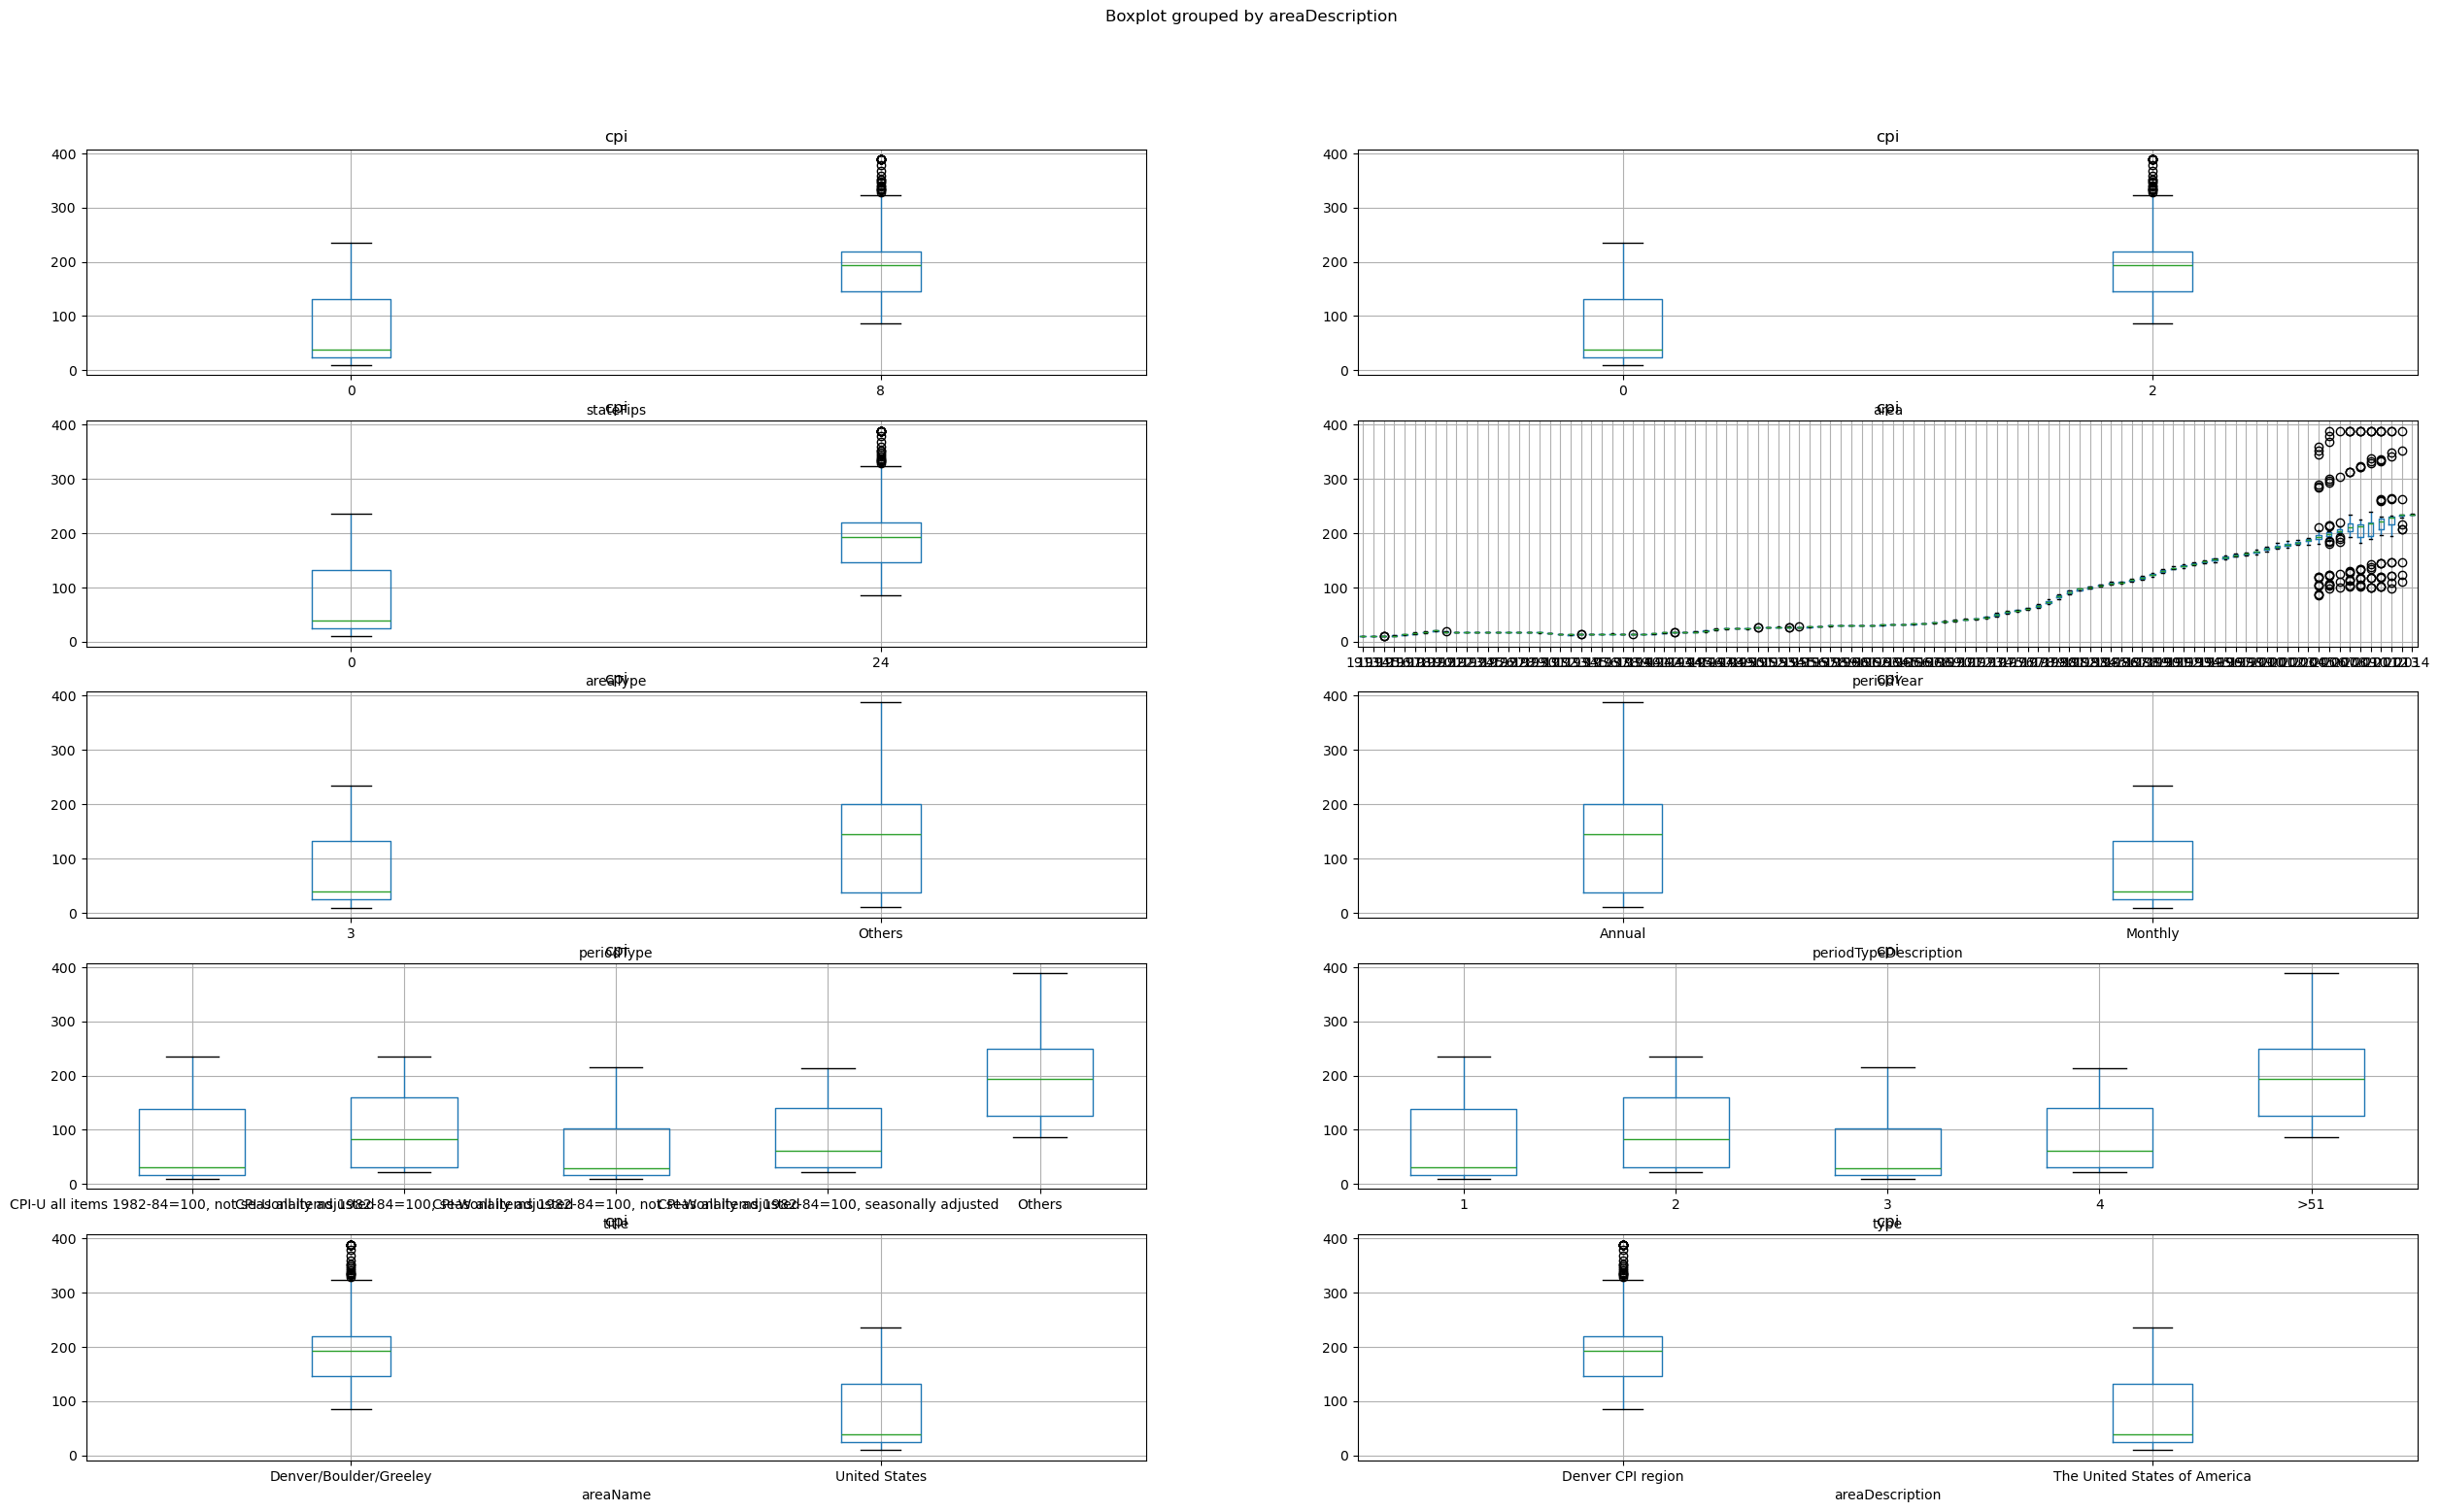

In [33]:
categoricalColumns=['stateFips', 'area', 'areaType', 'periodYear', 'periodType','periodTypeDescription','title','type','areaName','areaDescription']  
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(5,2,figsize=(30,18))
subplots=subplots.flatten() 
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Consumer_Price_Index_Data.boxplot(column='cpi',by=cols,vert=True,ax=subplots[no_of_cols])

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [34]:
categoricalColumns=['stateFips', 'area', 'areaType', 'periodYear', 'periodType','periodTypeDescription','title','type','areaName','areaDescription'] 
def functionAnova(inpData,categoricalColumns,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[] 
    for cols in categoricalColumns:
        CategoricalGroupLists=Consumer_Price_Index_Data.groupby(cols)[targetVariable].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,' is  correlated with cpi and P value is:',AnovaResults[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with cpi and P value is:',AnovaResults[1])
    return SelectedPredictors
functionAnova(Consumer_Price_Index_Data,categoricalColumns,'cpi')

stateFips  is  correlated with cpi and P value is: 3.169979408603131e-175
area  is  correlated with cpi and P value is: 3.169979408603131e-175
areaType  is  correlated with cpi and P value is: 3.169979408603131e-175
periodYear  is  correlated with cpi and P value is: 0.0
periodType  is  correlated with cpi and P value is: 1.2466330015275587e-78
periodTypeDescription  is  correlated with cpi and P value is: 1.2466330015275587e-78
title  is  correlated with cpi and P value is: 4.971372456665206e-175
type  is  correlated with cpi and P value is: 4.971372456665206e-175
areaName  is  correlated with cpi and P value is: 3.169979408603131e-175
areaDescription  is  correlated with cpi and P value is: 3.169979408603131e-175


['stateFips',
 'area',
 'areaType',
 'periodYear',
 'periodType',
 'periodTypeDescription',
 'title',
 'type',
 'areaName',
 'areaDescription']

## Selecting final predictors for Machine Learning

In [43]:
SelectedColumns=['stateFips',
 'area',
 'areaType', 
 'periodYear',
 'periodType',
 'periodTypeDescription',
 'title',
 'type',
 'areaName', 
 'areaDescription','percentChangeYear', 'percentChangeMonth']
DataForMLConsumer_Price_Index_Data=Consumer_Price_Index_Data[SelectedColumns]
DataForMLConsumer_Price_Index_Data.to_pickle('DataForMLConsumer_Price_Index_Data.pkl')
DataForMLConsumer_Price_Index_Data=pd.read_pickle('DataForMLConsumer_Price_Index_Data.pkl')
DataForMLConsumer_Price_Index_Data.head()

,stateFips,area,areaType,periodYear,periodType,periodTypeDescription,title,type,areaName,areaDescription,percentChangeYear,percentChangeMonth
0,0,0,0,1913,Others,Annual,"CPI-U all items 1982-84=100, not seasonally ad...",1,United States,The United States of America,0.0,0.0
1,0,0,0,1913,Others,Annual,"CPI-W all items 1982-84=100, not seasonally ad...",3,United States,The United States of America,0.0,0.0
2,0,0,0,1913,3,Monthly,"CPI-U all items 1982-84=100, not seasonally ad...",1,United States,The United States of America,0.0,-1.0
3,0,0,0,1913,3,Monthly,"CPI-W all items 1982-84=100, not seasonally ad...",3,United States,The United States of America,0.0,-1.0
4,0,0,0,1913,3,Monthly,"CPI-U all items 1982-84=100, not seasonally ad...",1,United States,The United States of America,0.0,0.0


## Data Preprocessing for Machine Learning

In [36]:
pd.set_option('display.max_columns',None)

## Selecting final predictors for Machine Learning

## Converting the binary nominal variable to numeric using 1/0 mapping


In [44]:
DataForMLConsumer_Price_Index_Data_Numeric=pd.get_dummies(DataForMLConsumer_Price_Index_Data)
DataForMLConsumer_Price_Index_Data_Numeric.replace({True:1,False:0},inplace=True)
DataForMLConsumer_Price_Index_Data_Numeric.head() 

C:\Users\abrau\AppData\Local\Temp\ipykernel_105432\4266489835.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForMLConsumer_Price_Index_Data_Numeric.replace({True:1,False:0},inplace=True)


,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America
0,0,0,0,1913,0.0,0.0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,1913,0.0,0.0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1
2,0,0,0,1913,0.0,-1.0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1
3,0,0,0,1913,0.0,-1.0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1
4,0,0,0,1913,0.0,0.0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1


In [38]:
DataForMLConsumer_Price_Index_Data_Numeric=(DataForMLConsumer_Price_Index_Data_Numeric.apply(pd.to_numeric)) 

In [39]:
DataForMLConsumer_Price_Index_Data_Numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 24 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   stateFips                                                   4349 non-null   int64  
 1   area                                                        4349 non-null   int64  
 2   areaType                                                    4349 non-null   int64  
 3   periodYear                                                  4349 non-null   int64  
 4   percentChangeYear                                           4349 non-null   float64
 5   percentChangeMonth                                          4349 non-null   float64
 6   periodType_3                                                4349 non-null   int64  
 7   periodType_Others                                           4349 non-null   int64  
 8 

In [46]:
DataForMLConsumer_Price_Index_Data_Numeric.columns

Index(['stateFips', 'area', 'areaType', 'periodYear', 'percentChangeYear',
       'percentChangeMonth', 'periodType_3', 'periodType_Others',
       'periodTypeDescription_Annual', 'periodTypeDescription_Monthly',
       'title_CPI-U all items 1982-84=100, not seasonally adjusted',
       'title_CPI-U all items 1982-84=100, seasonally adjusted',
       'title_CPI-W all items 1982-84=100, not seasonally adjusted',
       'title_CPI-W all items 1982-84=100, seasonally adjusted',
       'title_Others', 'type_1', 'type_2', 'type_3', 'type_4', 'type_>51',
       'areaName_Denver/Boulder/Greeley', 'areaName_United States',
       'areaDescription_Denver CPI region',
       'areaDescription_The United States of America'],
      dtype='object')

In [88]:
DataForMLConsumer_Price_Index_Data_Numeric['cpi']=Consumer_Price_Index_Data['cpi']

In [48]:
DataForMLConsumer_Price_Index_Data_Numeric['cpi'].describe()

count    4349.000000
mean       83.054462
std        72.964399
min         9.700000
25%        25.500000
50%        42.400000
75%       142.600000
max       388.400000
Name: cpi, dtype: float64

In [ ]:
np.sqrt(mse)

In [89]:
DataForMLConsumer_Price_Index_Data_Numeric.head()

,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America,cpi
0,0,0,0,1913,0.0,0.0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,9.9
1,0,0,0,1913,0.0,0.0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,10.0
2,0,0,0,1913,0.0,-1.0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,9.8
3,0,0,0,1913,0.0,-1.0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,9.9
4,0,0,0,1913,0.0,0.0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,9.8


## Splitting the data into Training and Testing

In [49]:
targetVariable='cpi'
predictors=['stateFips', 'area', 'areaType', 'periodYear', 'percentChangeYear',
       'percentChangeMonth', 'periodType_3', 'periodType_Others',
       'periodTypeDescription_Annual', 'periodTypeDescription_Monthly',
       'title_CPI-U all items 1982-84=100, not seasonally adjusted',
       'title_CPI-U all items 1982-84=100, seasonally adjusted',
       'title_CPI-W all items 1982-84=100, not seasonally adjusted',
       'title_CPI-W all items 1982-84=100, seasonally adjusted',
       'title_Others', 'type_1', 'type_2', 'type_3', 'type_4', 'type_>51',
       'areaName_Denver/Boulder/Greeley', 'areaName_United States',
       'areaDescription_Denver CPI region',
       'areaDescription_The United States of America']
#predictors=[ 'periodYear', 'percentChangeYear']
X=DataForMLConsumer_Price_Index_Data_Numeric[predictors].values
y=DataForMLConsumer_Price_Index_Data_Numeric[targetVariable].values

# Polynomial Regression
#from sklearn.preprocessing import PolynomialFeatures
#poly=PolynomialFeatures(degree=2, include_bias=False)
#X=poly.fit_transform(X) 
#predictors=poly.get_feature_names_out()


from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3479, 24)
(3479,)
(870, 24)
(870,)


In [ ]:
X_train[0:5]

In [ ]:
y_train[0:5]

## Linear Regression

In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
RegModel=LinearRegression()
LREG=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round((metrics.r2_score(y_train,LREG.predict(X_train))*100),2),'%')
prediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults['Predicted'+targetVariable]=prediction
TestingDataResults[targetVariable]=y_test
# TestingDataResults.head() 
TestingDataResults['APE']= (abs(TestingDataResults[targetVariable]-TestingDataResults['Predicted'+targetVariable])/TestingDataResults[targetVariable])*100
# (TestingDataResults[['Predicted'+targetVariable,targetVariable,'APE']]).head(5)
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
mse = mean_squared_error(y_test, prediction)
print('mse',mse) 

def accuracy_Score(orig,pred):
    MAPE=np.mean((abs(orig-pred)/orig)*100)
    return 100-MAPE

from sklearn.metrics import make_scorer
custom_scoring=make_scorer(accuracy_Score,greater_is_better=True)

from sklearn.model_selection import cross_val_score
Accuracy_Values=cross_val_score(LREG,X,y,cv=5,scoring=custom_scoring)
print(Accuracy_Values)
print(np.mean(Accuracy_Values))

R2 Value: 78.71 %
29.760605262405207
67.63978149688288
mse 1079.322589802462
[-476.6831422    21.59249653  -13.32738769   90.6572394    65.72276324]
-62.40760614404853


## Decision Tree Regressor

R2 Value: 0.948
96.97638099347283
98.78808642538351
mse 357.76343669319476
[72.94963088 80.5305535  73.07978891 77.9011113  83.82955893]
Final Accuracy of the Model: 77.66 %


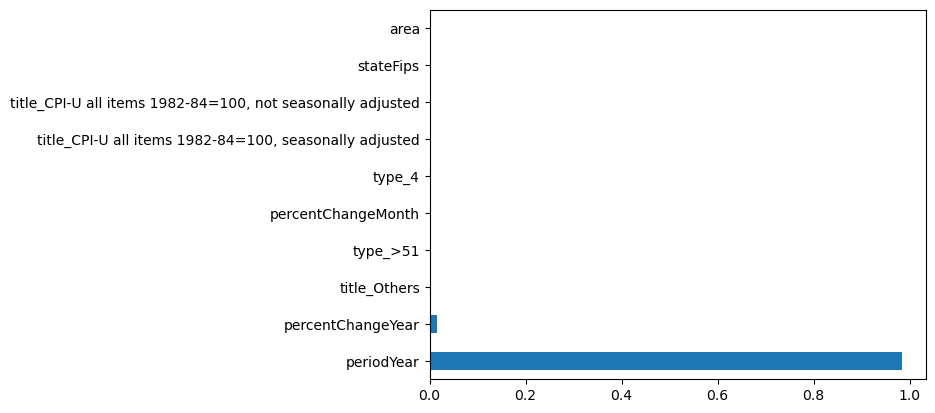

In [51]:
from sklearn.tree import DecisionTreeRegressor
RegModel=DecisionTreeRegressor(max_depth=7,criterion='squared_error')
DT=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round(metrics.r2_score(y_train,DT.predict(X_train)),3))

feature_importances=pd.Series(DT.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')

prediction=DT.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults['Predicted'+targetVariable]=prediction
TestingDataResults[targetVariable]=y_test
# TestingDataResults.head()
TestingDataResults['APE']= (abs(TestingDataResults[targetVariable]-TestingDataResults['Predicted'+targetVariable])/TestingDataResults[targetVariable])*100
# (TestingDataResults[['Predicted'+targetVariable,targetVariable,'APE']]).head(5)
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
mse = mean_squared_error(y_test, prediction)
print('mse',mse)

def accuracy_Score(orig,pred):
    MAPE=np.mean((abs(orig-pred)/orig)*100)
    return 100-MAPE

from sklearn.metrics import make_scorer
custom_scoring=make_scorer(accuracy_Score,greater_is_better=True)

from sklearn.model_selection import cross_val_score
Accuracy_Values=cross_val_score(DT,X,y,cv=5,scoring=custom_scoring)
print(Accuracy_Values)
print('Final Accuracy of the Model:',np.round(np.mean(Accuracy_Values),2),'%')

## Random Forest Regressor

RandomForestRegressor(n_estimators=200)
R2 Value: 0.9835452441007412
mse 423.4276258810417
Accuracy 97.77948059422637


,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America,cpi,Predictedcpi
0,0.0,0.0,0.0,1988.0,4.0,0.4,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,118.0,118.312292
1,0.0,0.0,0.0,2001.0,3.7,0.6,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,175.6,175.821458
2,0.0,0.0,0.0,2000.0,3.4,0.2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,174.2,172.576500
3,0.0,0.0,0.0,1952.0,2.0,0.2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,26.7,26.517317
4,0.0,0.0,0.0,1971.0,4.4,0.3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,40.0,40.542500


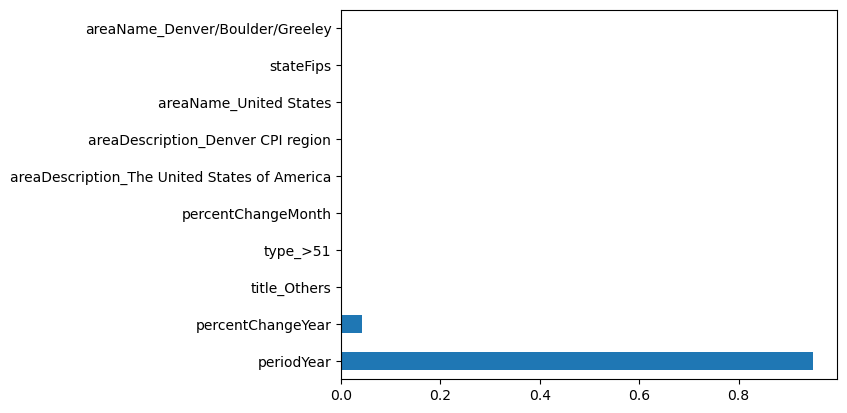

In [52]:
from sklearn.ensemble import RandomForestRegressor
RegModel = RandomForestRegressor(n_estimators=200,criterion='squared_error')
 
#Printing all the parameters of Random Forest
print(RegModel)
 
#Creating the model on Training Data
RF=RegModel.fit(X_train,y_train)
prediction=RF.predict(X_test) 
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, RF.predict(X_train)))
mse = mean_squared_error(y_test, prediction)
print('mse',mse)
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

## XGBRegressor

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.008, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)
R2 Value: 0.9497845501168989
Final Accuracy of the Model 94.57 %


,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America,cpi,Predictedcpi
0,0.0,0.0,0.0,1988.0,4.0,0.4,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,118.0,117.361290
1,0.0,0.0,0.0,2001.0,3.7,0.6,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,175.6,177.402863
2,0.0,0.0,0.0,2000.0,3.4,0.2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,174.2,169.318176
3,0.0,0.0,0.0,1952.0,2.0,0.2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,26.7,27.676210
4,0.0,0.0,0.0,1971.0,4.4,0.3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,40.0,41.295906


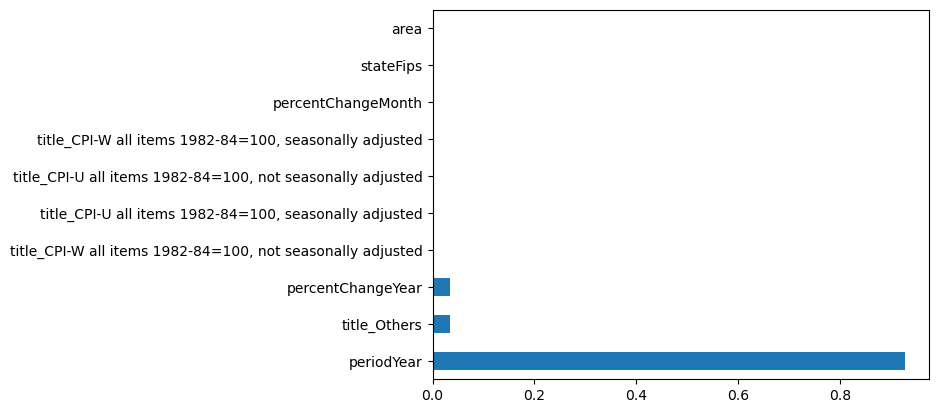

In [87]:
from xgboost import XGBRegressor
RegModel=XGBRegressor(max_depth=4, learning_rate=0.008, n_estimators=500, objective='reg:squarederror', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(RegModel)
 
#Creating the model on Training Data
XGB=RegModel.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics  
print('R2 Value:',metrics.r2_score(y_train, XGB.predict(X_train)))
 
#Measuring accuracy on Testing Data
print('Final Accuracy of the Model:',round(100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100),2),'%')
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()


## AdaBoost Regressor

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                  learning_rate=0.1, n_estimators=100)
R2 Value: 0.9427683881564859
Accuracy 94.03308285504339


,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America,cpi,Predictedcpi
0,0.0,0.0,0.0,1988.0,4.0,0.4,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,118.0,115.825581
1,0.0,0.0,0.0,2001.0,3.7,0.6,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,175.6,177.905714
2,0.0,0.0,0.0,2000.0,3.4,0.2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,174.2,169.709524
3,0.0,0.0,0.0,1952.0,2.0,0.2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,26.7,25.909286
4,0.0,0.0,0.0,1971.0,4.4,0.3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,40.0,41.224615


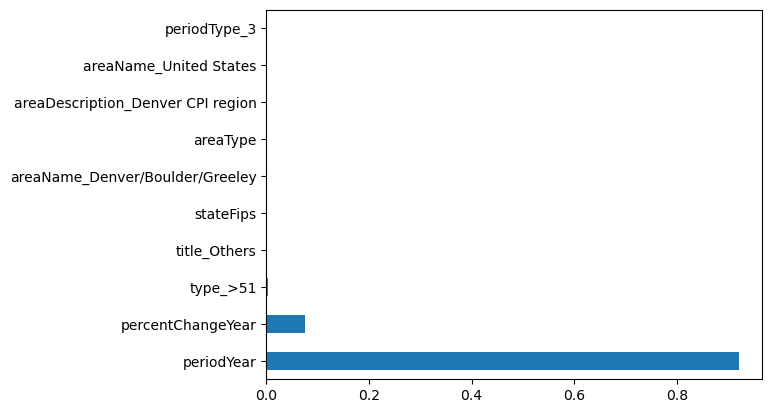

In [54]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
 
#Choosing Decision Tree with 1 level as the weak learner
DTR=DecisionTreeRegressor(max_depth=5)
RegModel = AdaBoostRegressor(n_estimators=100, estimator=DTR,learning_rate=0.1)
 
#Printing all the parameters of Adaboost
print(RegModel)
 
#Creating the model on Training Data
AB=RegModel.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, AB.predict(X_train)))
 
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline 
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors) 
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

# Selected XGBoost Model and Deploying on the Sample Data

In [95]:
NewData=pd.DataFrame(data=[
[0,0,0,1921,1.7,-0.4,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1],
[0,0,0,1935,2.3,0.6,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1],
[0,0,0,1948,3.9,-0.8,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1],
[0,0,0,1956,1.2,0.3,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1],
[0,0,0,1962,4.1,-0.5,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1],

[0,0,0,1971,5.6,0.9,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1],
[0,0,0,1978,2.8,-0.2,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,1],
[0,0,0,1983,6.4,1.1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1],
[0,0,0,1988,1.9,0.0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1],
[0,0,0,1991,3.3,-0.6,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1],

[0,0,0,1995,4.7,0.5,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1],
[0,0,0,1998,2.1,-0.1,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1],
[0,0,0,2001,3.8,0.7,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1],
[0,0,0,2005,5.2,-0.3,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0,1],
[0,0,0,2008,1.5,0.2,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1],

[0,0,0,2012,2.9,-0.4,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1],
[0,0,0,2015,4.4,0.8,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,1],
[0,0,0,2018,3.1,-0.7,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1],
[0,0,0,2021,6.0,1.2,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1],
[0,0,0,2024,4.8,0.4,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1]
]
,columns=predictors)
NewData

,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America
0,0,0,0,1921,1.7,-0.4,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,1935,2.3,0.6,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1
2,0,0,0,1948,3.9,-0.8,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1
3,0,0,0,1956,1.2,0.3,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1
4,0,0,0,1962,4.1,-0.5,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1
5,0,0,0,1971,5.6,0.9,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1
6,0,0,0,1978,2.8,-0.2,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,1
7,0,0,0,1983,6.4,1.1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1
8,0,0,0,1988,1.9,0.0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1
9,0,0,0,1991,3.3,-0.6,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1


In [96]:
newX=NewData.values

In [97]:
DT.predict(newX)

array([ 17.56573705,  14.02832618,  24.20675676,  26.76042553,
        30.73559322,  40.635     ,  63.37857143,  99.95428571,
       117.04411765, 136.44285714, 149.88095238, 161.39534884,
       179.00859375, 192.825     , 205.08571429, 236.05537255,
       236.05537255, 236.05537255, 236.05537255, 236.05537255])

In [98]:
def GeneratePred(inpData):
    newX=NewData.values
    pred=DT.predict(newX)
    inpData['Prediction']=pred
    return (inpData) 

In [99]:
GeneratePred(inpData=NewData)

,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America,Prediction
0,0,0,0,1921,1.7,-0.4,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,17.565737
1,0,0,0,1935,2.3,0.6,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,14.028326
2,0,0,0,1948,3.9,-0.8,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,24.206757
3,0,0,0,1956,1.2,0.3,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,26.760426
4,0,0,0,1962,4.1,-0.5,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,30.735593
5,0,0,0,1971,5.6,0.9,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,40.635000
6,0,0,0,1978,2.8,-0.2,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,1,63.378571
7,0,0,0,1983,6.4,1.1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,99.954286
8,0,0,0,1988,1.9,0.0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,117.044118
9,0,0,0,1991,3.3,-0.6,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1,136.442857
